In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

print("Movies Shape:", movies.shape)
print("Ratings Shape:", ratings.shape)

Movies Shape: (27278, 3)
Ratings Shape: (20000263, 4)


In [3]:
ratings = ratings.sample(
    n=10000,
    random_state=42
)

print(ratings.shape)

(10000, 4)


In [4]:
data = pd.merge(
    ratings,
    movies,
    on="movieId"
)

data.head()

,userId,movieId,rating,timestamp,title,genres
0,122270,8360,3.5,1335056824,Shrek 2 (2004),Adventure|Animation|Children|Comedy|Musical|Ro...
1,49018,32,2.0,1000194636,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
2,89527,109374,3.5,1420536400,"Grand Budapest Hotel, The (2014)",Comedy|Drama
3,106704,1060,3.0,948576477,Swingers (1996),Comedy|Drama
4,47791,1732,2.0,1137685703,"Big Lebowski, The (1998)",Comedy|Crime


In [5]:
user_movie_matrix = data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)

user_movie_matrix = user_movie_matrix.fillna(0)

print(user_movie_matrix.shape)

(8959, 3368)


In [6]:
item_similarity = cosine_similarity(
    user_movie_matrix.T
)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

print(item_similarity_df.shape)

(3368, 3368)


In [7]:
def recommend_movies(movie_name, n=10):

    similar_movies = item_similarity_df[
        movie_name
    ].sort_values(
        ascending=False
    )

    return similar_movies.iloc[1:n+1]

In [8]:
movie_name = user_movie_matrix.columns[0]

print("Selected Movie:")
print(movie_name)

recommendations = recommend_movies(
    movie_name,
    10
)

print("\nRecommended Movies:")
print(recommendations)

Selected Movie:
'burbs, The (1989)

Recommended Movies:
title
(500) Days of Summer (2009)                               0.0
*batteries not included (1987)                            0.0
10 Things I Hate About You (1999)                         0.0
10,000 BC (2008)                                          0.0
101 Dalmatians (1996)                                     0.0
101 Dalmatians (One Hundred and One Dalmatians) (1961)    0.0
101 Reykjavik (101 Reykjavík) (2000)                      0.0
12 Angry Men (1957)                                       0.0
12 Rounds (2009)                                          0.0
12 Years a Slave (2013)                                   0.0
Name: 'burbs, The (1989), dtype: float64


In [9]:
train, test = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [10]:
global_mean = train["rating"].mean()

predictions = np.full(
    len(test),
    global_mean
)

rmse = np.sqrt(
    mean_squared_error(
        test["rating"],
        predictions
    )
)

mae = mean_absolute_error(
    test["rating"],
    predictions
)

print("RMSE =", rmse)
print("MAE =", mae)

RMSE = 1.0600194886917176
MAE = 0.8462167500000001


In [11]:
top_movies = (
    data.groupby("title")["rating"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print(top_movies)

title
Year of Living Dangerously, The (1982)          5.0
Xiu Xiu: The Sent-Down Girl (Tian yu) (1998)    5.0
21 Up (1977)                                    5.0
Born into Brothels (2004)                       5.0
Seconds (1966)                                  5.0
Ringu (Ring) (1998)                             5.0
Return to Me (2000)                             5.0
Gone Girl (2014)                                5.0
Formula 51 (2001)                               5.0
Forgetting Sarah Marshall (2008)                5.0
Name: rating, dtype: float64


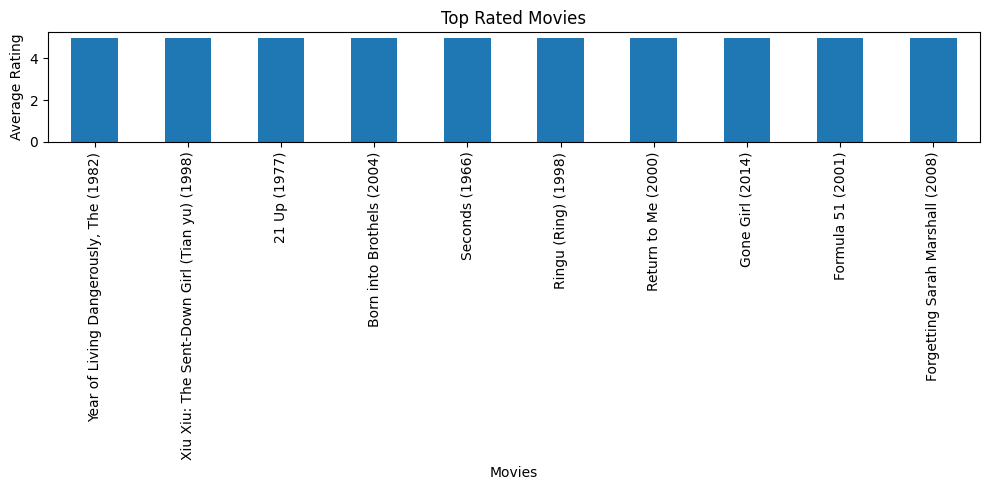

In [12]:
top_movies.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Rated Movies")
plt.xlabel("Movies")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [13]:
print("="*50)
print("MOVIE RECOMMENDATION SYSTEM")
print("="*50)

print("\nTop Recommendations:")
print(recommendations)

print("\nEvaluation Metrics")
print("RMSE =", round(rmse,4))
print("MAE  =", round(mae,4))

print("\nProject Completed Successfully")

MOVIE RECOMMENDATION SYSTEM

Top Recommendations:
title
(500) Days of Summer (2009)                               0.0
*batteries not included (1987)                            0.0
10 Things I Hate About You (1999)                         0.0
10,000 BC (2008)                                          0.0
101 Dalmatians (1996)                                     0.0
101 Dalmatians (One Hundred and One Dalmatians) (1961)    0.0
101 Reykjavik (101 Reykjavík) (2000)                      0.0
12 Angry Men (1957)                                       0.0
12 Rounds (2009)                                          0.0
12 Years a Slave (2013)                                   0.0
Name: 'burbs, The (1989), dtype: float64

Evaluation Metrics
RMSE = 1.06
MAE  = 0.8462

Project Completed Successfully
